In [1]:
import torch
import matplotlib.pyplot as plt
import random
import torch.nn.functional as F
%matplotlib inline

In [2]:
words = open('names.txt','r').read().splitlines()

In [3]:
charset = sorted(set("".join(words)))

stoi = {s:i+1 for i,s in enumerate(charset)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

vocab_size = len(stoi)

In [4]:
random.shuffle(words)
block_size = 3

In [5]:
def build_dataset(words):
    X = []
    y = []
    for w in words:
        context = [0] * block_size
        for ch in w+'.':
            ix = stoi[ch]
            y.append(ix)
            X.append(context)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    y = torch.tensor(y)
    return X, y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

X_train, y_train = build_dataset(words[:n1])
X_test, y_test = build_dataset(words[n1:n2])
X_val, y_val = build_dataset(words[n2:])

In [44]:
class Linear:
    def __init__(self,fan_in,fan_out,bias=True):
        self.weights = torch.randn((fan_in,fan_out)) / fan_in**0.5
        if bias:
            self.bias = torch.zeros((fan_out)) 
        else:
            self.bias = None

    def __call__(self,x):
        self.out = x @ self.weights
        if self.bias is None:
            return self.out 
        return self.out + self.bias
    
    def parameters(self):
        return [self.weights] + ([] if self.bias is None else [self.bias])
    
class BatchNorm1d:
    def __init__(self,dim,eps=1e-5,momentum=0.01):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        #grad variables
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        #no-grad variables
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        if self.training:
            x_mean = x.mean(0,keepdims=True)
            x_var = x.var(0,keepdims=True,unbiased=True)
        else:
            x_mean = self.running_mean
            x_var = self.running_var
        xhat = (x-x_mean)/torch.sqrt(x_var**2 + self.eps)
        self.out = self.gamma*xhat + self.beta
        if self.training:
            with torch.no_grad():
                self.running_mean = (1-self.momentum)*self.running_mean + self.momentum*x_mean
                self.running_var = (1-self.momentum)*self.running_var + self.momentum*x_var
        return self.out

    def parameters(self):
        return [self.gamma,self.beta]
    
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

        


In [45]:
n_emb = 10
n_hidden = 100

C = torch.randn((vocab_size,n_emb))
layers = [
  Linear(n_emb * block_size,  n_hidden), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, vocab_size), BatchNorm1d(vocab_size)
]

with torch.no_grad():
  # layers[-1].weights *= 0.1
  layers[-1].gamma *= 0.1
  for layer in layers[:-1]:
    if isinstance(layer, Linear):
      layer.weights *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

47551


In [46]:
iterations = 200000
batch_size = 32
lossi = []
ud = []

for i in range(iterations):
    ix = torch.randint(0,len(X_train),(batch_size,))
    Xb, yb = X_train[ix], y_train[ix]

    emb = C[Xb]
    x = emb.view(batch_size,-1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x,yb)

    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr*p.grad

    if i%10000 == 0:
        print(f'{i:7d}/{iterations:7d}: Loss={loss.item():.4f}')
    lossi.append(loss)
    with torch.no_grad():
        ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])
    if i> 1000:
        break




      0/ 200000: Loss=3.2761


layer 2 (      Tanh): mean -0.00, std 0.51, saturated: 0.69%
layer 5 (      Tanh): mean -0.01, std 0.67, saturated: 6.22%
layer 8 (      Tanh): mean -0.00, std 0.56, saturated: 0.72%
layer 11 (      Tanh): mean +0.00, std 0.65, saturated: 3.97%
layer 14 (      Tanh): mean +0.00, std 0.54, saturated: 0.38%


Text(0.5, 1.0, 'activation distribution')

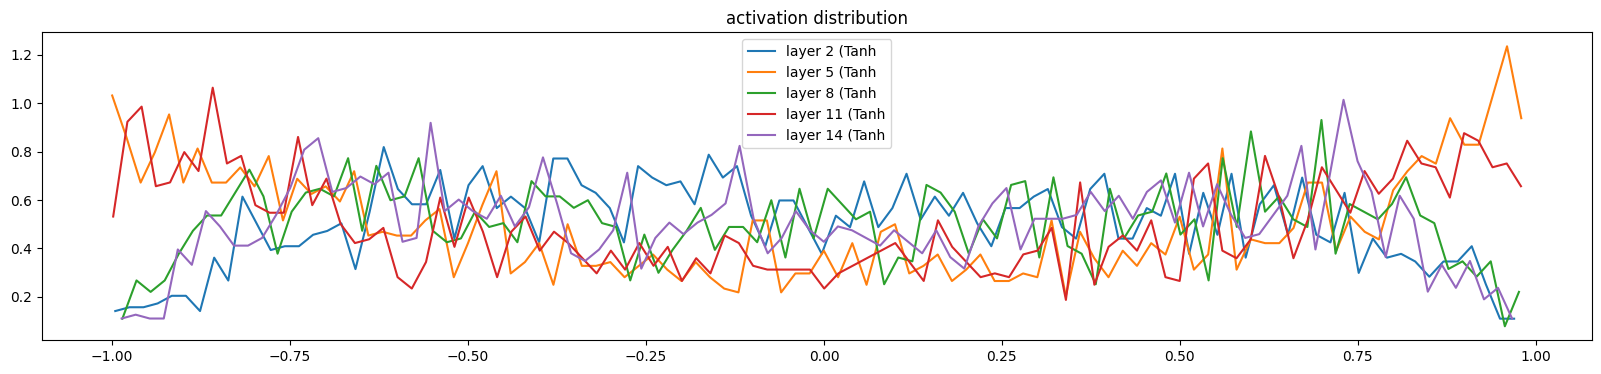

In [47]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

layer 2 (      Tanh): mean -0.00, std 0.00, saturated: 0.00%
layer 5 (      Tanh): mean -0.00, std 0.00, saturated: 0.00%
layer 8 (      Tanh): mean +0.00, std 0.00, saturated: 0.00%
layer 11 (      Tanh): mean -0.00, std 0.00, saturated: 0.00%
layer 14 (      Tanh): mean -0.00, std 0.00, saturated: 0.00%


Text(0.5, 1.0, 'activation distribution')

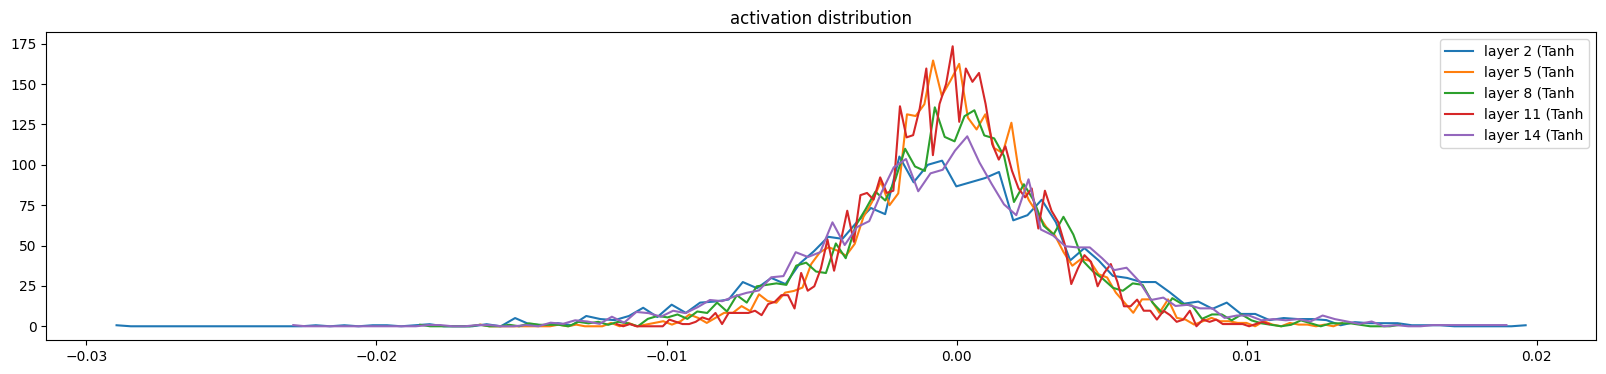

In [48]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

weight   (27, 10) | mean +0.000000 | std 1.173954e-02 | grad:data ratio 1.202602e-02
weight  (30, 100) | mean -0.000529 | std 1.120903e-02 | grad:data ratio 3.686332e-02
weight (100, 100) | mean -0.000018 | std 8.611408e-03 | grad:data ratio 5.132932e-02
weight (100, 100) | mean +0.000164 | std 7.084009e-03 | grad:data ratio 4.194115e-02
weight (100, 100) | mean +0.000036 | std 7.533339e-03 | grad:data ratio 4.495881e-02
weight (100, 100) | mean -0.000074 | std 6.921098e-03 | grad:data ratio 4.118277e-02
weight  (100, 27) | mean +0.000562 | std 1.673926e-02 | grad:data ratio 1.024174e-01


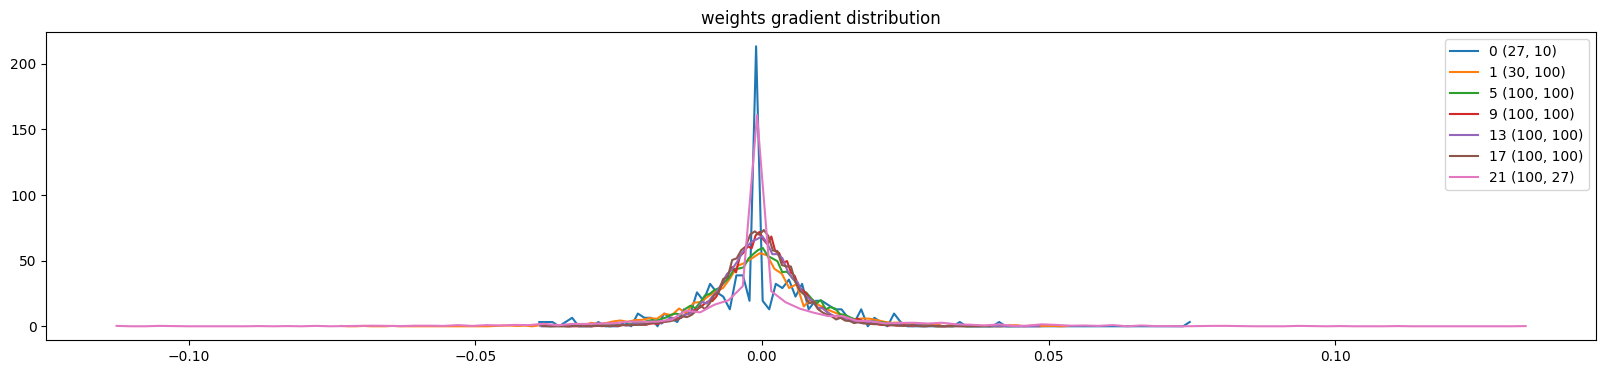

In [49]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

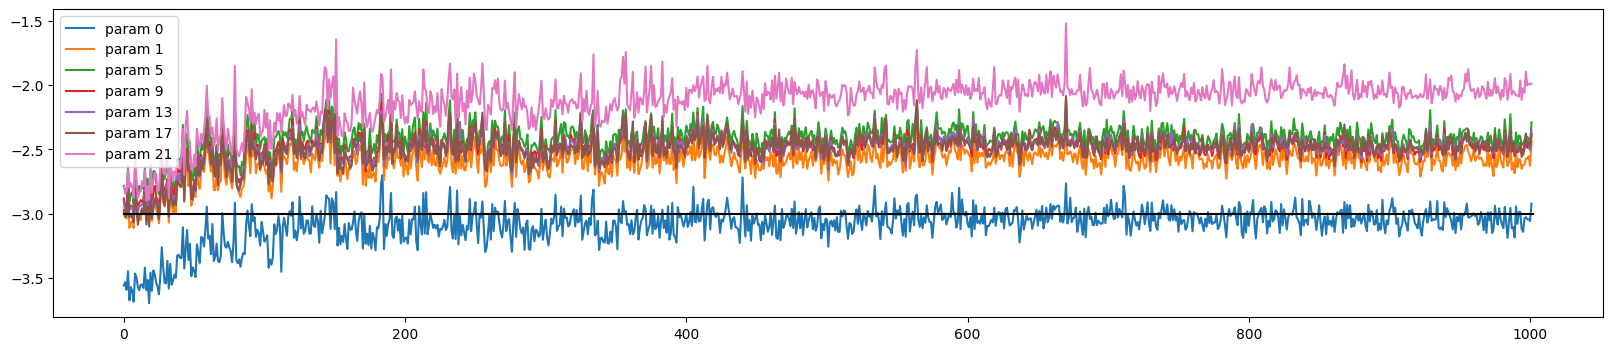

In [50]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);
